In [4]:
from dotenv import load_dotenv
from IPython.display import Image, display
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langchain_mcp_adapters.client import MultiServerMCPClient

load_dotenv(override=True)

True

In [5]:
agent = create_agent(
    model="openai:gpt-5.4-mini",
    system_prompt="You are a helpful assistant who answers concisely.",
)

result = agent.invoke({"messages": [{"role": "user", "content": "What is the Model Context Protocol, in two sentences?"}]})
print(result["messages"][-1].content)

result = await agent.ainvoke({"messages": [{"role": "user", "content": "In one sentence: why does async code suit agents so well?"}]})
print(result["messages"][-1].content)

The Model Context Protocol (MCP) is an open standard for connecting AI models and applications to external tools, data sources, and services in a consistent way. It lets a model access context and capabilities through a common interface, making integrations easier and more reusable.
Async code suits agents well because agents spend much of their time waiting on external I/O, so async lets them handle many tasks concurrently without blocking.


Rome is currently **sunny, 27 degrees**, and its population is **2.8 million**.


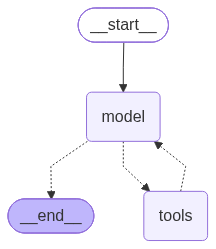

In [6]:
@tool
def get_weather(city: str) -> str:
    """Return today's weather for a city."""
    pretend = {"London": "rainy, 14 degrees", "Rome": "sunny, 27 degrees"}
    return pretend.get(city, "clear, 20 degrees")

@tool
def get_population(city: str) -> str:
    """Return the population of a city."""
    pretend = {"London": "8.9 million", "Rome": "2.8 million"}
    return pretend.get(city, "unknown")

agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[get_weather, get_population],
    system_prompt="You are a travel assistant. Use your tools to answer questions about cities.",
)

result = agent.invoke({"messages": [{"role": "user", "content": "What is the weather and population of Rome?"}]})
print(result["messages"][-1].content)
display(Image(agent.get_graph().draw_mermaid_png()))

In [7]:
memory_agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[get_weather],
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": "trip-planning"}}
memory_agent.invoke({"messages": [{"role": "user", "content": "I am planning a trip to London."}]}, config=config)
result = memory_agent.invoke({"messages": [{"role": "user", "content": "What is the weather like where I am going on my trip?"}]}, config=config)
print(result["messages"][-1].content)

The weather in **London** is **rainy and 14°C**. 

If you want, I can also suggest what to pack for that weather.


In [8]:
class CityReport(BaseModel):
    city: str = Field(description="The city name")
    weather: str = Field(description="A short weather description")
    population: str = Field(description="The population")

report_agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[get_weather, get_population],
    response_format=CityReport,
)

result = report_agent.invoke({"messages": [{"role": "user", "content": "Give me a report on London."}]})
report = result["structured_response"]
print(report)
print("Just the weather:", report.weather)

city='London' weather='rainy, 14 degrees' population='8.9 million'
Just the weather: rainy, 14 degrees


In [9]:
@wrap_tool_call
def log_tool_calls(request, handler):
    call = request.tool_call
    print(f"  [middleware] calling {call['name']} with {call['args']}")
    return handler(request)

watched_agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[get_weather, get_population],
    system_prompt="You are a travel assistant. Use your tools.",
    middleware=[log_tool_calls],
)

result = watched_agent.invoke({"messages": [{"role": "user", "content": "Weather and population of London and Rome?"}]})
print("\nFinal answer:", result["messages"][-1].content)

  [middleware] calling get_population with {'city': 'Rome'}  [middleware] calling get_population with {'city': 'London'}

  [middleware] calling get_weather with {'city': 'London'}
  [middleware] calling get_weather with {'city': 'Rome'}

Final answer: Here you go:

- London: rainy, 14°C; population 8.9 million
- Rome: sunny, 27°C; population 2.8 million


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹Navigating to https://news.ycombinator.com
Capturing screenshot into playwright_check.png
⠙npm notice
npm notice New major version of npm available! 11.17.0 -> 12.0.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.1
npm notice To update run: npm install -g npm@12.0.1
npm notice
⠙

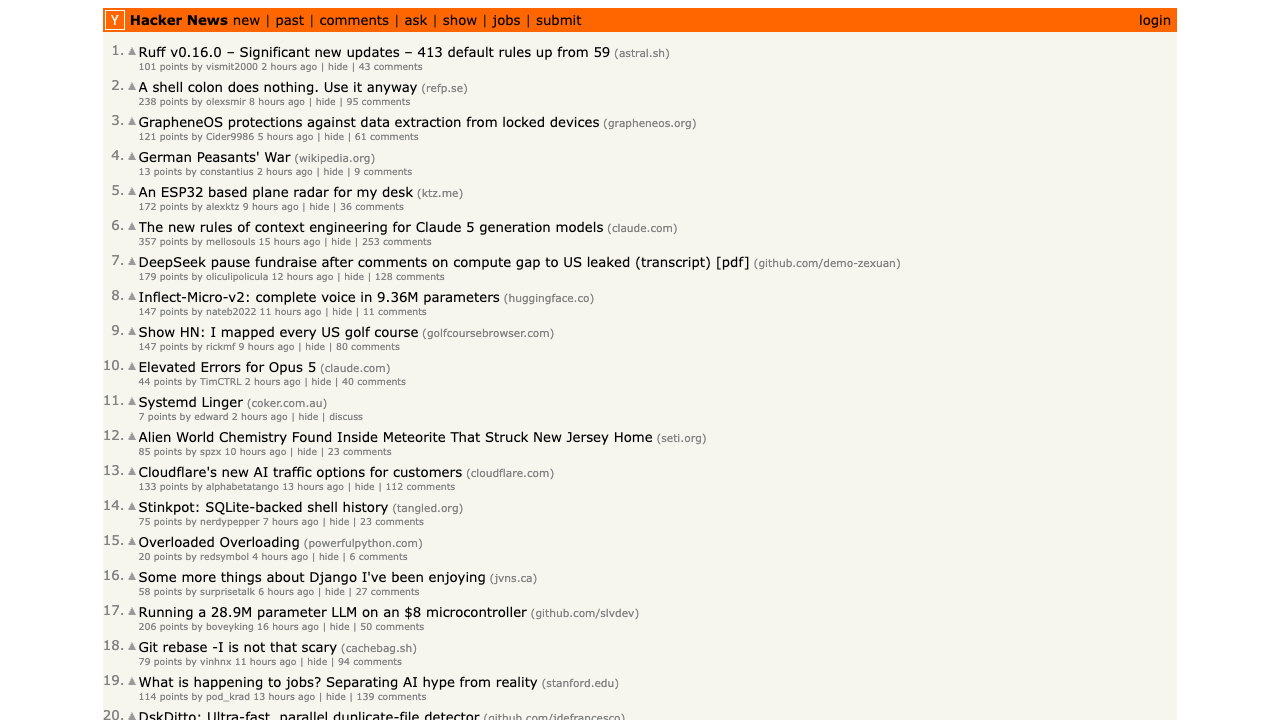

Not Windows, so nothing to do here
Loaded 24 browser tools:
 - browser_close
 - browser_resize
 - browser_console_messages
 - browser_handle_dialog
 - browser_evaluate
 - browser_file_upload
 - browser_drop
 - browser_find
 - browser_fill_form
 - browser_press_key
 - browser_type
 - browser_navigate
 - browser_navigate_back
 - browser_network_requests
 - browser_network_request
 - browser_run_code_unsafe
 - browser_take_screenshot
 - browser_snapshot
 - browser_click
 - browser_drag
 - browser_hover
 - browser_select_option
 - browser_tabs
 - browser_wait_for
The top three stories on Hacker News are:

1. Ruff v0.16.0 – Significant new updates – 413 default rules up from 59  
2. A shell colon does nothing. Use it anyway  
3. GrapheneOS protections against data extraction from locked devices


In [12]:
!npx -y playwright@latest screenshot --channel=chrome https://news.ycombinator.com playwright_check.png
display(Image("playwright_check.png"))

import sys

if sys.platform == "win32":
    import subprocess
    from functools import partial
    import langchain_mcp_adapters.sessions as mcp_sessions

    mcp_sessions.stdio_client = partial(mcp_sessions.stdio_client, errlog=subprocess.DEVNULL)
    print("Applied the Windows adjustment")
else:
    print("Not Windows, so nothing to do here")

client = MultiServerMCPClient({
    "playwright": {
        "transport": "stdio",
        "command": "npx",
        "args": ["-y", "@playwright/mcp@latest", "--isolated"],
    }
})

browser_tools = await client.get_tools()
print(f"Loaded {len(browser_tools)} browser tools:")
for t in browser_tools:
    print(" -", t.name)

browser_agent = create_agent(
    model="openai:gpt-5.5",
    tools=browser_tools,
    system_prompt="You are a web research assistant. Use the browser tools to complete the task, then report clearly.",
)

result = await browser_agent.ainvoke({"messages": [{"role": "user",
    "content": "Go to https://news.ycombinator.com and tell me the titles of the top three stories on the front page."}]})
print(result["messages"][-1].content)